# Zero-Shot Wildfire Scene Understanding: Grounding DINO + SAM, with MobileSAM on TensorRT

A foundation-model pipeline for fire-lookout cameras with **no task-specific training**. Grounding DINO finds regions that match a text prompt
(smoke, haze, dry vegetation, power lines, buildings), and SAM turns each box into a pixel mask. The segmentation encoder is then
re-targeted to the edge by exporting **MobileSAM** to a TensorRT engine.

Scored against the dataset's **ground-truth smoke boxes** (744 images, one plume each):

| | Prompt v1 | Prompt v2 (+ synonyms) | Prompt v2 + cross-phrase NMS |
|---|---|---|---|
| Images with any smoke detection | 59.3% | **77.7%** | 77.7% |
| Plume localised (IoU ≥ 0.5) | 35.5% | **50.8%** | 50.7% |
| Precision of smoke boxes (IoU ≥ 0.5) | **57.4%** | 24.2% | 47.3% |
| AP50 | 0.255 | 0.267 | **0.304** |

| Edge optimisation | Value |
|---|---|
| MobileSAM image encoder, TensorRT engine (1×3×1024×1024) | mean **4.31 ms**, p99 4.38 ms (≈ 232 FPS) over 698 runs |

**How to read this notebook.** Result cells run on artefacts in `results/`: detections, ground-truth boxes and engine timings. The detection pass
(Grounding DINO + SAM ViT-H) and the TensorRT build need the checkpoints and a CUDA GPU and were not re-executed here. The ground-truth scoring was added while
this repository was packaged.

## 0 · Setup

In [1]:
import io, json, os
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from PIL import Image
from IPython.display import Markdown, display, Image as IPyImage

RESULTS = Path("results")          # everything saved from the original runs lives here
FIG = RESULTS / "figures"

def show(path, width=1100, caption=None):
    """Display a saved result image, downscaled so the notebook stays small."""
    im = Image.open(path).convert("RGB")
    if im.width > width:
        im = im.resize((width, round(im.height * width / im.width)), Image.LANCZOS)
    buf = io.BytesIO(); im.save(buf, format="JPEG", quality=85)
    if caption:
        display(Markdown(f"*{caption}*"))
    display(IPyImage(data=buf.getvalue(), format="jpeg"))

def show_pair(left, right, titles=("", ""), width=1400, gap=12):
    """Two result images side by side (e.g. ground truth vs prediction), embedded as one JPEG."""
    ims = [Image.open(p).convert("RGB") for p in (left, right)]
    h = min(im.height for im in ims)
    ims = [im.resize((round(im.width * h / im.height), h), Image.LANCZOS) for im in ims]
    canvas = Image.new("RGB", (ims[0].width + gap + ims[1].width, h), (252, 252, 251))
    canvas.paste(ims[0], (0, 0)); canvas.paste(ims[1], (ims[0].width + gap, 0))
    if canvas.width > width:
        canvas = canvas.resize((width, round(canvas.height * width / canvas.width)), Image.LANCZOS)
    buf = io.BytesIO(); canvas.save(buf, format="JPEG", quality=85)
    if any(titles):
        display(Markdown(f"*Left: {titles[0]} · Right: {titles[1]}*"))
    display(IPyImage(data=buf.getvalue(), format="jpeg"))

# Chart style: light surface, hairline grid, text in ink colours, fixed categorical order.
SERIES = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100"]
INK, INK2, MUTED = "#0b0b0b", "#52514e", "#898781"
mpl.rcParams.update({
    "figure.facecolor": "#fcfcfb", "axes.facecolor": "#fcfcfb", "savefig.facecolor": "#fcfcfb",
    "axes.edgecolor": "#c3c2b7", "axes.grid": True, "axes.axisbelow": True,
    "grid.color": "#e1e0d9", "grid.linewidth": 0.8, "grid.linestyle": "-",
    "axes.spines.top": False, "axes.spines.right": False,
    "text.color": INK, "axes.labelcolor": INK2, "axes.titlecolor": INK,
    "axes.titlesize": 12, "axes.titleweight": "semibold", "axes.titlelocation": "left",
    "xtick.color": MUTED, "ytick.color": MUTED, "xtick.labelcolor": INK2, "ytick.labelcolor": INK2,
    "lines.linewidth": 2, "lines.solid_capstyle": "round", "legend.frameon": False,
    "axes.prop_cycle": mpl.cycler(color=SERIES), "figure.dpi": 110, "savefig.dpi": 160,
})

import sys
sys.path.insert(0, "src")
from eval_against_gt import evaluate, iou, is_smoke
M = RESULTS / "metrics"
gt = {r.image: [r.xmin, r.ymin, r.xmax, r.ymax] for r in pd.read_csv(M / "gt_boxes.csv").itertuples()}
dets = {v: json.load(open(M / f"detections_{v}.json")) for v in ("v1", "v2")}
print(len(gt), "ground-truth smoke boxes;", {v: sum(len(x) for x in d.values()) for v, d in dets.items()}, "detections")

744 ground-truth smoke boxes; {'v1': 1970, 'v2': 4966} detections


## 1 · Data

The [AI For Mankind](https://github.com/aiformankind/wildfire-smoke-dataset) bounding-box set: **744 images from HPWREN fire-lookout cameras**,
640×480, each with one annotated smoke plume (Pascal VOC). `src/load_sequence.py` wraps a folder as a simulated camera feed, sorted by file name.
File names are annotation-tool IDs, so the images come from **many different cameras and days**. The folder is a collection, not a time-lapse, which matters for tracking (section 6).

## 2 · Zero-shot detection → segmentation (`src/detect_and_segment.py`)

For each frame, Grounding DINO (Swin-T) scores the image against a `.`-separated phrase list (box threshold 0.25, text threshold 0.20). Each box is then passed
to SAM ViT-H as a box prompt, which returns a pixel mask. Two prompt versions were run over all 744 images:

* **v1:** `smoke plume . dry vegetation . power line . building`
* **v2:** `smoke plume . wildfire smoke . haze . smoke . dry vegetation . power line . building` (synonyms added to recover thin smoke; `haze` added as a distractor class)

In [ ]:
"""
Zero-shot scene understanding pipeline: Grounding DINO detects objects from
a text prompt (no training), boxes are fed into SAM for pixel-accurate
masks. Saves annotated frames and a per-frame detections JSON.

Usage:
    python detect_and_segment.py --frames data/raw --out outputs/annotated \
        --checkpoints checkpoints/
"""
import argparse
import json
import os
from pathlib import Path

import cv2
import numpy as np
import torch
import groundingdino
from groundingdino.util.inference import load_model, load_image, predict, annotate
from segment_anything import sam_model_registry, SamPredictor

GROUNDING_DINO_CONFIG = os.path.join(
    os.path.dirname(groundingdino.__file__), "config", "GroundingDINO_SwinT_OGC.py"
)

TEXT_PROMPT = "smoke plume . wildfire smoke . haze . smoke . dry vegetation . power line . building"
BOX_THRESHOLD = 0.25
TEXT_THRESHOLD = 0.20


def run_pipeline(frames_dir: Path, out_dir: Path, checkpoints_dir: Path):
    device = "cuda" if torch.cuda.is_available() else "cpu"
    print(f"Using device: {device}")

    dino_model = load_model(
        GROUNDING_DINO_CONFIG,
        str(checkpoints_dir / "groundingdino_swint_ogc.pth"),
    )

    sam = sam_model_registry["vit_h"](checkpoint=str(checkpoints_dir / "sam_vit_h_4b8939.pth"))
    sam.to(device)
    predictor = SamPredictor(sam)

    out_dir.mkdir(parents=True, exist_ok=True)
    all_detections = {}

    frame_paths = sorted(
        list(frames_dir.glob("*.jpg"))
        + list(frames_dir.glob("*.jpeg"))
        + list(frames_dir.glob("*.png"))
    )
    print(f"Processing {len(frame_paths)} frames...")

    for i, frame_path in enumerate(frame_paths):
        image_source, image = load_image(str(frame_path))

        boxes, logits, phrases = predict(
            model=dino_model,
            image=image,
            caption=TEXT_PROMPT,
            box_threshold=BOX_THRESHOLD,
            text_threshold=TEXT_THRESHOLD,
        )

        h, w, _ = image_source.shape
        annotated_frame = image_source.copy()
        frame_detections = []

        if len(boxes) > 0:
            predictor.set_image(image_source)

            # Grounding DINO boxes are normalized cxcywh -> convert to xyxy pixels
            boxes_xyxy = boxes.clone()
            boxes_xyxy[:, 0] = (boxes[:, 0] - boxes[:, 2] / 2) * w
            boxes_xyxy[:, 1] = (boxes[:, 1] - boxes[:, 3] / 2) * h
            boxes_xyxy[:, 2] = (boxes[:, 0] + boxes[:, 2] / 2) * w
            boxes_xyxy[:, 3] = (boxes[:, 1] + boxes[:, 3] / 2) * h

            for box, phrase, conf in zip(boxes_xyxy, phrases, logits):
                box_np = box.cpu().numpy()
                mask, score, _ = predictor.predict(
                    box=box_np, multimask_output=False
                )
                mask = mask[0]

                # overlay mask
                color = np.random.randint(0, 255, 3)
                overlay = np.zeros_like(annotated_frame)
                overlay[mask] = color
                annotated_frame = cv2.addWeighted(annotated_frame, 1.0, overlay, 0.4, 0)

                cv2.rectangle(
                    annotated_frame,
                    (int(box_np[0]), int(box_np[1])),
                    (int(box_np[2]), int(box_np[3])),
                    color.tolist(), 2,
                )
                cv2.putText(
                    annotated_frame, f"{phrase} {float(conf):.2f}",
                    (int(box_np[0]), int(box_np[1]) - 8),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.5, color.tolist(), 1,
                )

                mask_path = out_dir / f"{frame_path.stem}_{phrase.replace(' ', '_')}_mask.npy"
                np.save(mask_path, mask)

                frame_detections.append({
                    "phrase": phrase,
                    "confidence": float(conf),
                    "box_xyxy": box_np.tolist(),
                    "mask_path": str(mask_path),
                })

        out_path = out_dir / frame_path.name
        cv2.imwrite(str(out_path), cv2.cvtColor(annotated_frame, cv2.COLOR_RGB2BGR))
        all_detections[frame_path.name] = frame_detections

        print(f"[{i+1}/{len(frame_paths)}] {frame_path.name}: {len(frame_detections)} detections")

    with open(out_dir / "detections.json", "w") as f:
        json.dump(all_detections, f, indent=2)

    print(f"\nDone. Annotated frames + detections.json written to {out_dir}")


if __name__ == "__main__":
    parser = argparse.ArgumentParser()
    parser.add_argument("--frames", type=Path, required=True)
    parser.add_argument("--out", type=Path, required=True)
    parser.add_argument("--checkpoints", type=Path, required=True)
    args = parser.parse_args()
    run_pipeline(args.frames, args.out, args.checkpoints)

## 3 · Results against ground truth (`src/eval_against_gt.py`)

A detection counts as *smoke* when its phrase mentions smoke or plume. Grounding DINO sometimes merges phrases, e.g. `smoke plume wildfire smoke`.
Each image has exactly one ground-truth plume, so any extra smoke box is a false positive.

In [2]:
def cross_phrase_nms(dets, thr=0.5):
    """Keep the most confident of overlapping smoke boxes, whichever synonym produced them."""
    out = {}
    for k, ds in dets.items():
        keep = []
        for d in sorted([d for d in ds if is_smoke(d["phrase"])], key=lambda d: -d["confidence"]):
            if all(iou(d["box_xyxy"], kd["box_xyxy"]) < thr for kd in keep):
                keep.append(d)
        out[k] = keep + [d for d in ds if not is_smoke(d["phrase"])]
    return out

runs = {"prompt v1": dets["v1"], "prompt v2": dets["v2"], "prompt v2 + cross-phrase NMS": cross_phrase_nms(dets["v2"])}
summary = pd.DataFrame({name: evaluate(gt, d)[1] for name, d in runs.items()}).T
summary.to_csv(M / "gt_eval_summary.csv")
summary[["smoke_boxes", "image_recall", "hit_iou03", "hit_iou05", "precision_iou05", "AP50"]].round(3)

,smoke_boxes,image_recall,hit_iou03,hit_iou05,precision_iou05,AP50
prompt v1,460.0,0.593,0.367,0.355,0.574,0.255
prompt v2,1563.0,0.777,0.528,0.508,0.242,0.267
prompt v2 + cross-phrase NMS,797.0,0.777,0.528,0.507,0.473,0.304


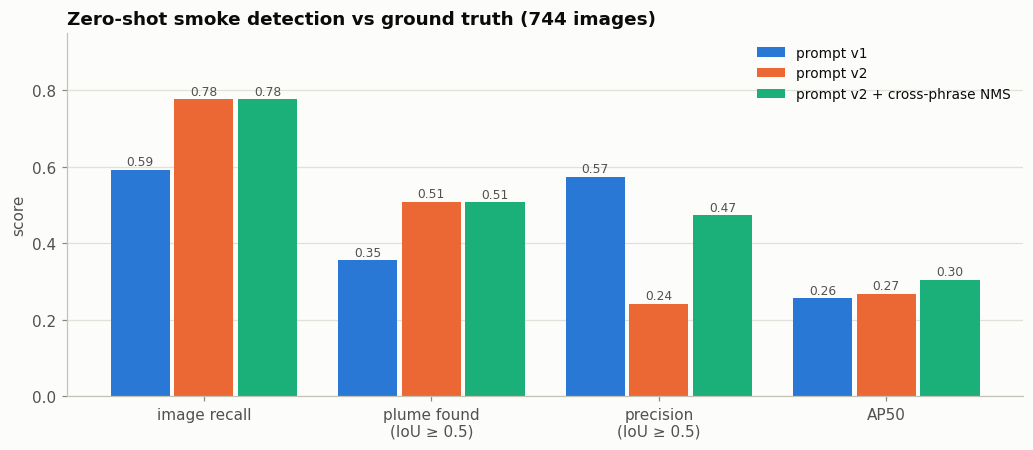

In [3]:
cols = {"image_recall": "image recall", "hit_iou05": "plume found\n(IoU ≥ 0.5)", "precision_iou05": "precision\n(IoU ≥ 0.5)", "AP50": "AP50"}
x = np.arange(len(cols)); w = 0.26
fig, ax = plt.subplots(figsize=(9.5, 4.2))
for j, (name, color) in enumerate(zip(summary.index, SERIES)):
    vals = summary.loc[name, list(cols)].astype(float).values
    bars = ax.bar(x + (j - 1) * (w + 0.02), vals, width=w, color=color, label=name)
    for b, v in zip(bars, vals):
        ax.text(b.get_x() + b.get_width() / 2, v + 0.012, f"{v:.2f}", ha="center", fontsize=8, color=INK2)
ax.set_xticks(x, list(cols.values())); ax.set_ylim(0, 0.95); ax.set_ylabel("score")
ax.set_title("Zero-shot smoke detection vs ground truth (744 images)")
ax.legend(loc="upper right", fontsize=9); ax.grid(axis="x", visible=False)
plt.tight_layout(); fig.savefig(FIG / "gt_evaluation.png"); plt.show()

* **Synonyms raise recall.** Adding `wildfire smoke` / `smoke` / `haze` lifts localised plumes from 35.5% to 50.8% of images.
* **But they flood duplicates.** The same plume is boxed once per synonym, so precision falls from 57% to 24%. Merging smoke boxes across phrases (NMS at IoU 0.5)
  removes half of the v2 smoke boxes, restores precision to 47%, and gives the best AP50 (0.304) with no loss of recall.
* **Misses are genuine misses.** In no image does a non-smoke phrase overlap the plume at IoU ≥ 0.3, so smoke is not being mislabelled as something else.
  Small, distant or faint plumes are simply not detected, or are swallowed by a whole-sky `haze` box.
* All 744 images contain smoke, so the false-alarm rate on smoke-free scenes (cloud, fog, dust) is **not measured here**. It would need the dataset's separate no-smoke images.

Six cases, one image each: prompt-v2 output (masks and boxes) with the ground-truth plume in white. Three plumes are localised, and three show the typical failures.

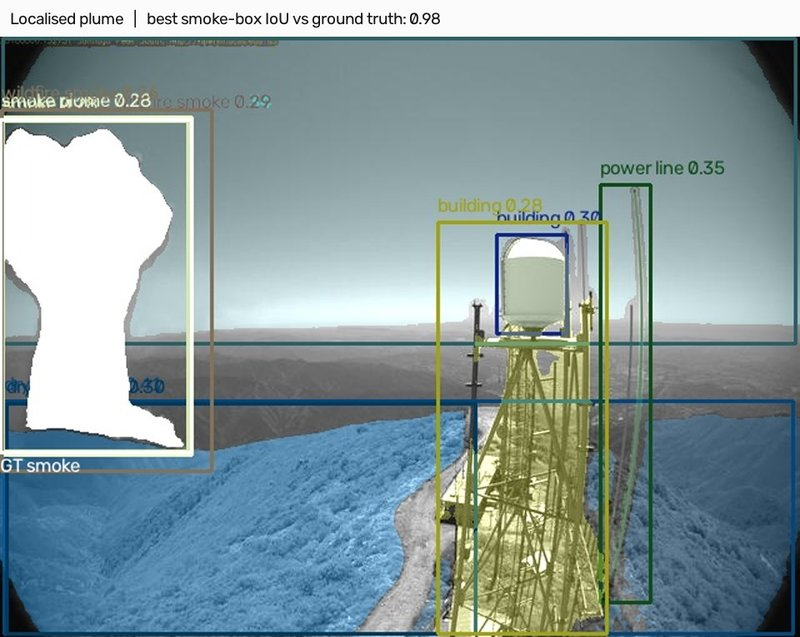

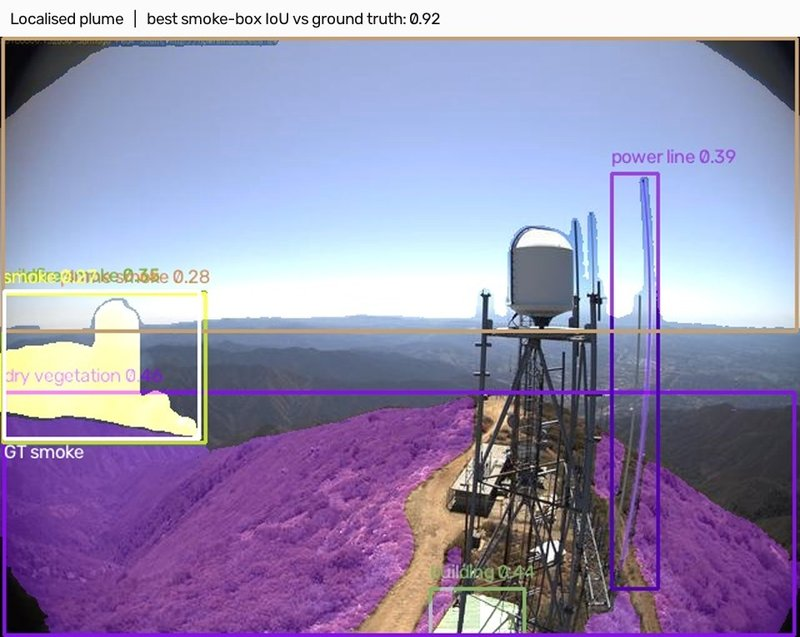

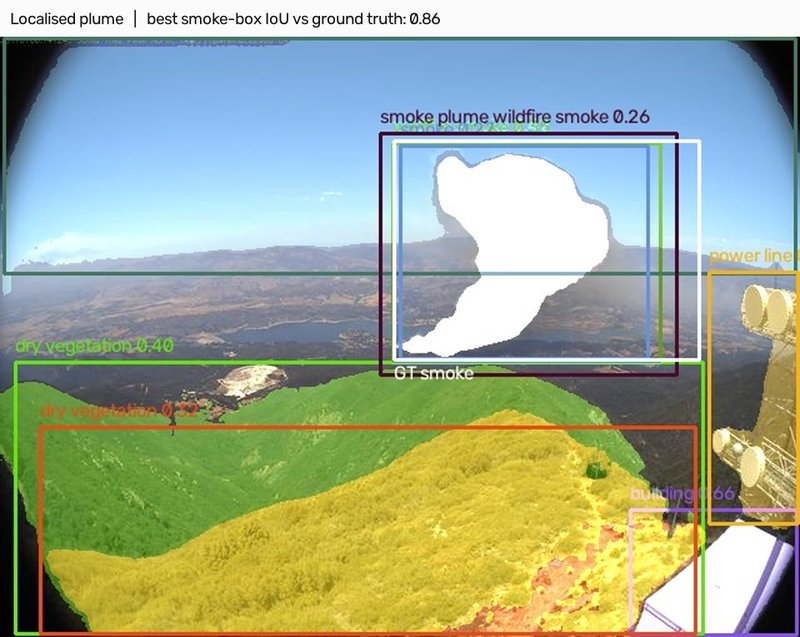

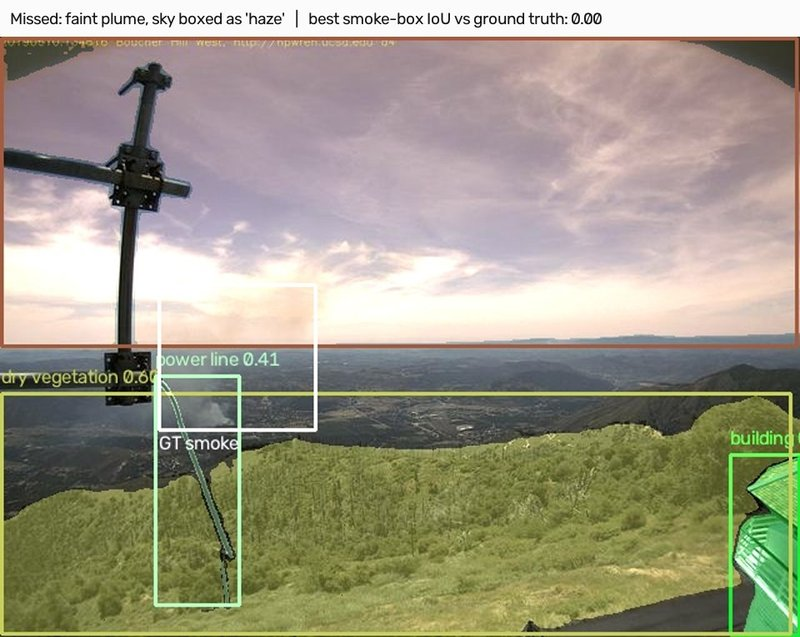

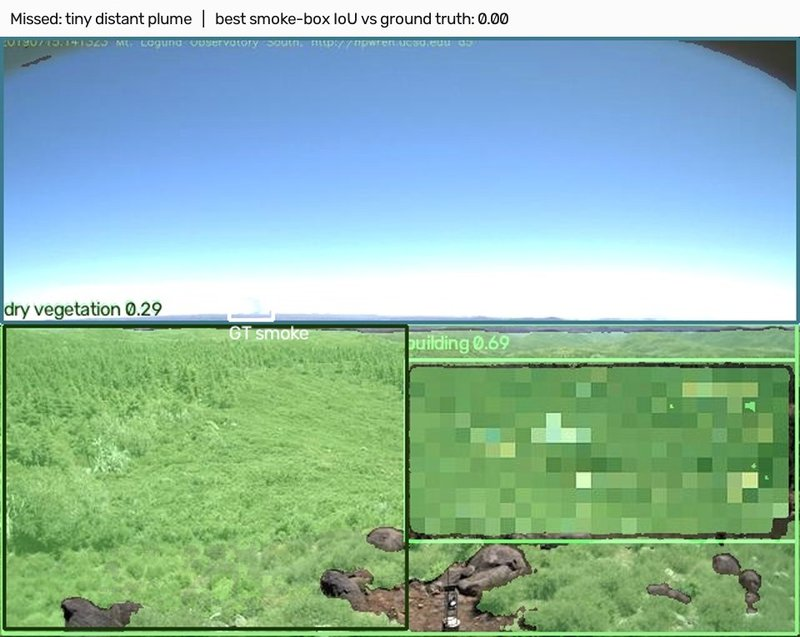

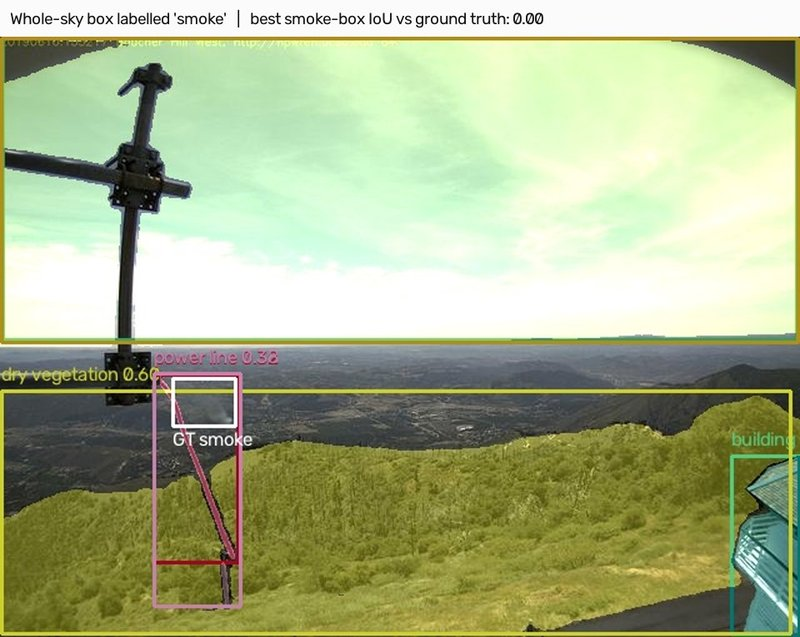

In [4]:
for case in ["hit_1", "hit_2", "hit_3", "miss_faint_plume", "miss_tiny_plume", "wrong_whole_sky_box"]:
    show(FIG / "examples" / f"{case}.jpg", width=800)

## 4 · Edge optimisation: MobileSAM → ONNX → TensorRT (`src/export_onnx.py`, `src/export_and_build.sh`)

SAM ViT-H (636M parameters) runs per frame and does not export cleanly, so the segmentation stage was re-targeted to **MobileSAM**. Its TinyViT image encoder is
distilled from SAM and keeps SAM's prompt encoder and mask decoder. The encoder, which is the per-frame heavy part, is exported to ONNX (opset 17, 1×3×1024×1024 → 1×256×64×64)
and built with `trtexec`. Grounding DINO stays in PyTorch because its text branch is dynamic; that scoping choice is recorded in `docs/limitations.md`.

In [ ]:
import subprocess
subprocess.run(["python", "src/export_onnx.py", "--checkpoint", "checkpoints/mobile_sam.pt", "--output", "optimize/exported/mobile_sam_encoder.onnx"], check=True)
subprocess.run(["trtexec", "--onnx=optimize/exported/mobile_sam_encoder.onnx", "--saveEngine=optimize/exported/mobile_sam.engine",
                "--exportTimes=results/metrics/mobile_sam_trt_timings.json"], check=True)

,runs,mean ms,p50 ms,p99 ms,max ms,throughput (1/mean)
MobileSAM encoder (TensorRT),698.0,4.31,4.32,4.38,4.47,231.78


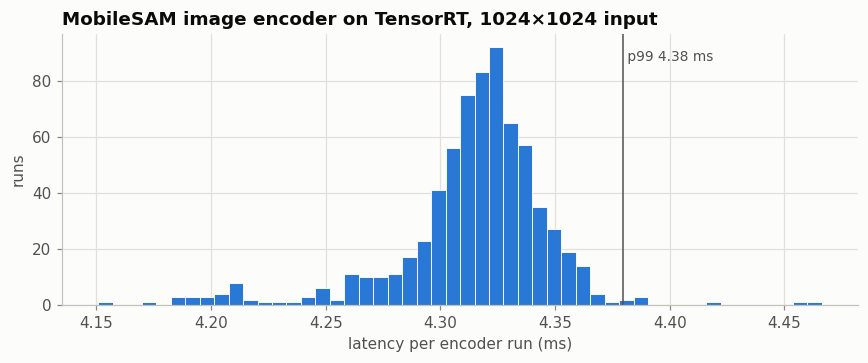

In [5]:
t = json.load(open(M / "mobile_sam_trt_timings.json"))
lat = np.array([r.get("latencyMs", r.get("computeMs")) for r in t])
display(pd.Series({"runs": len(lat), "mean ms": lat.mean(), "p50 ms": np.percentile(lat, 50), "p99 ms": np.percentile(lat, 99),
                   "max ms": lat.max(), "throughput (1/mean)": 1000 / lat.mean()}).round(2).to_frame("MobileSAM encoder (TensorRT)").T)
fig, ax = plt.subplots(figsize=(8, 3.4))
ax.hist(lat, bins=50, color=SERIES[0], edgecolor="#fcfcfb", linewidth=0.6)
ax.axvline(np.percentile(lat, 99), color=INK2, lw=1); ax.text(np.percentile(lat, 99), ax.get_ylim()[1] * 0.9, f" p99 {np.percentile(lat, 99):.2f} ms", fontsize=9, color=INK2)
ax.set_xlabel("latency per encoder run (ms)"); ax.set_ylabel("runs"); ax.set_title("MobileSAM image encoder on TensorRT, 1024×1024 input")
plt.tight_layout(); fig.savefig(FIG / "mobile_sam_trt_latency.png"); plt.show()

The graph is FP32 and TensorRT 11 builds strongly-typed networks, so this is an FP32 engine. `src/benchmark.py` contains the PyTorch-vs-TensorRT
comparison, but that comparison was not run, so no speed-up factor is claimed. The detection pass above used **SAM ViT-H in PyTorch**. MobileSAM has been
benchmarked but is not yet wired into the pipeline.

## 5 · Tracking and the demo video: what went wrong (`src/track_and_render.py`)

The render script takes the most confident smoke mask per frame, appends its centroid to a trajectory, draws the growing line and writes a video
with a "TensorRT: 232 FPS" overlay. On this dataset the output is misleading for two reasons:

*Frame 400 of the original demo video: the 'trajectory' links plume centroids from unrelated cameras.*

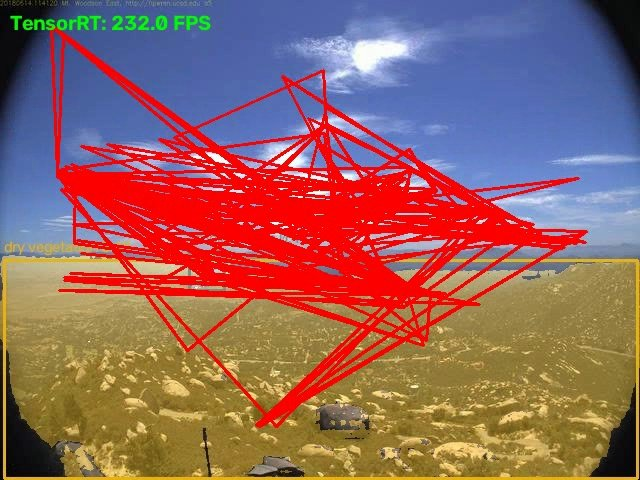

In [6]:
show(FIG / "demo_video_trajectory_issue.jpg", width=640, caption="Frame 400 of the original demo video: the 'trajectory' links plume centroids from unrelated cameras.")

1. **There is no temporal sequence.** Consecutive files are different cameras and days, so the "trajectory" connects unrelated plumes into a scribble. Centroid tracking needs a real time-lapse, and HPWREN publishes per-camera image sequences for each fire.
2. **The FPS label does not describe the pipeline shown.** 232 FPS is the MobileSAM encoder alone on TensorRT. The frames on screen were produced by Grounding DINO + SAM ViT-H in PyTorch.

For these reasons the video is not used as a result here. The annotated frames and the ground-truth scores above are the results.

## 6 · Limitations and next steps

* Add cross-phrase NMS to the pipeline, and tune the box threshold per phrase against the ground truth instead of one global 0.25.
* Measure false alarms on the dataset's **no-smoke** images (clouds and fog are the known confusers).
* Swap SAM ViT-H for the MobileSAM TensorRT engine (encoder) + the PyTorch mask decoder, then benchmark the full pipeline per frame.
* Re-run tracking on genuine HPWREN time-lapse sequences.
* The absolute numbers are a *zero-shot* baseline. A detector fine-tuned on these boxes would be the natural comparison.